# 01_cleaning_data

## imports + path setup

In [5]:
# 01_cleaning_data.ipynb
# Purpose: Load KOF globalization index dataset, filter to 32 countries, clean, sanity-check, and save processed file.

from pathlib import Path
import sys
import pandas as pd

# Repo root = parent of /notebooks
REPO_ROOT = Path.cwd().resolve().parents[0]
SRC_PATH = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

RAW_PATH = REPO_ROOT / "data" / "raw" / "KOF_index_raw.xlsx"
OUT_PARQUET = REPO_ROOT / "data" / "processed" / "kofgi_32countries_1980_2023.parquet"
OUT_CSV = REPO_ROOT / "data" / "processed" / "kofgi_32countries_1980_2023.csv"

print("REPO_ROOT:", REPO_ROOT)
print("SRC_PATH:", SRC_PATH)
print("RAW_PATH exists:", RAW_PATH.exists())
print("OUT folder exists:", OUT_PARQUET.parent.exists())

REPO_ROOT: C:\Users\Anton\economics-of-the-welfare-state
SRC_PATH: C:\Users\Anton\economics-of-the-welfare-state\src
RAW_PATH exists: True
OUT folder exists: True


## Import your cleaning utilities (module in src/clean/kofgi.py)

In [6]:
# Import the cleaning functions from your src/clean/kofgi.py
from clean.kofgi import (
    KOFConfig,
    read_kof_excel,
    standardize_kof,
    filter_kof_32countries,
    assert_exact_32,
    save_processed,
)

print("Imported cleaning utilities successfully.")


Imported cleaning utilities successfully.


## Load the Excel file

In [ ]:
# Load raw data
df_raw = read_kof_excel(RAW_PATH, sheet_name="Sheet1")

print("Raw shape:", df_raw.shape)
print("Columns (first 30):", list(df_raw.columns)[:30])
df_raw.head()


Raw shape: (11610, 30)
Columns (first 30): ['code', 'country', 'year', 'KOFGI', 'KOFGIdf', 'KOFGIdj', 'KOFEcGI', 'KOFEcGIdf', 'KOFEcGIdj', 'KOFTrGI', 'KOFTrGIdf', 'KOFTrGIdj', 'KOFFiGI', 'KOFFiGIdf', 'KOFFiGIdj', 'KOFSoGI', 'KOFSoGIdf', 'KOFSoGIdj', 'KOFIpGI', 'KOFIpGIdf', 'KOFIpGIdj', 'KOFInGI', 'KOFInGIdf', 'KOFInGIdj', 'KOFCuGI', 'KOFCuGIdf', 'KOFCuGIdj', 'KOFPoGI', 'KOFPoGIdf', 'KOFPoGIdj']


,code,country,year,KOFGI,KOFGIdf,KOFGIdj,KOFEcGI,KOFEcGIdf,KOFEcGIdj,KOFTrGI,...,KOFIpGIdj,KOFInGI,KOFInGIdf,KOFInGIdj,KOFCuGI,KOFCuGIdf,KOFCuGIdj,KOFPoGI,KOFPoGIdf,KOFPoGIdj
0,ABW,Aruba,1970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,1971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,1974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Standardize (types, trimming, name harmonization)

In [9]:
df_std = standardize_kof(df_raw)

print("Standardized shape:", df_std.shape)
df_std[["code", "country", "year"]].head(10)


Standardized shape: (11610, 31)


,code,country,year
0,ABW,Aruba,1970
1,ABW,Aruba,1971
2,ABW,Aruba,1972
3,ABW,Aruba,1973
4,ABW,Aruba,1974
5,ABW,Aruba,1975
6,ABW,Aruba,1976
7,ABW,Aruba,1977
8,ABW,Aruba,1978
9,ABW,Aruba,1979


## Filter to the 32 countries + optional year window

In [ ]:
cfg = KOFConfig(
    year_min=1980,
    year_max=2023,
    drop_all_missing_index=True
)

df_32 = filter_kof_32countries(df_std, cfg=cfg)

print("Filtered (32 countries) shape:", df_32.shape)
df_32.head()

Filtered (32 countries) shape: (1340, 30)


,iso3,country,year,KOFGI,KOFGIdf,KOFGIdj,KOFEcGI,KOFEcGIdf,KOFEcGIdj,KOFTrGI,...,KOFIpGIdj,KOFInGI,KOFInGIdf,KOFInGIdj,KOFCuGI,KOFCuGIdf,KOFCuGIdj,KOFPoGI,KOFPoGIdf,KOFPoGIdj
0,AUS,Australia,1980,62.259674,63.792107,60.769981,46.758671,35.515549,58.001797,48.250042,...,46.014587,58.188461,62.277504,54.099407,81.380493,80.179512,82.581474,75.070831,86.731979,63.409683
1,AUS,Australia,1981,62.196213,63.176628,61.243160,47.319584,34.043442,60.595722,47.269646,...,46.501312,58.197704,62.277504,54.117912,80.889000,80.203156,81.574844,74.404846,86.407272,62.402424
2,AUS,Australia,1982,62.148006,63.268391,61.058907,47.408798,34.237152,60.580448,46.937378,...,47.025208,58.230247,62.311886,54.148609,81.372437,80.404892,82.339989,73.919006,86.413017,61.424995
3,AUS,Australia,1983,62.404575,63.663292,61.180984,48.223728,35.306656,61.140789,46.599045,...,47.151669,58.252586,62.313744,54.191433,81.342079,80.590836,82.093323,73.849777,86.442871,61.256691
4,AUS,Australia,1984,62.434082,62.960182,61.922665,49.074951,35.124634,63.025265,46.908257,...,47.676720,58.289711,62.336620,54.242809,81.217270,80.588402,81.846138,73.036034,84.584549,61.487522


## Sanity checks (countries, years, duplicates)

In [11]:
# Hard assertion: ensures you truly have exactly the expected 32 ISO3 codes
assert_exact_32(df_32)

print("✅ ISO3 unique:", df_32["iso3"].nunique())
print("✅ Country unique:", df_32["country"].nunique())
print("✅ Year range:", int(df_32["year"].min()), "-", int(df_32["year"].max()))

# check duplicates on (iso3, year)
dup = df_32.duplicated(subset=["iso3", "year"]).sum()
print("Duplicate (iso3, year) rows:", dup)

# Quick peek at a few countries' coverage
df_32.groupby("iso3")["year"].agg(["min","max","count"]).sort_values("count").head(10)

✅ ISO3 unique: 32
✅ Country unique: 32
✅ Year range: 1980 - 2023
Duplicate (iso3, year) rows: 0


,min,max,count
iso3,,,
SVK,1993,2023,31
CZE,1993,2023,31
SVN,1991,2023,33
EST,1991,2023,33
LVA,1990,2023,34
LTU,1990,2023,34
AUS,1980,2023,44
PRT,1980,2023,44
POL,1980,2023,44


## Inspect missingness in key KOF columns (so we don’t regress on NaN soup)

In [ ]:
# Identify "index columns" heuristically (common in KOF files)
index_cols = [c for c in df_32.columns if c.startswith("KOF") or c.startswith("KOFGI")]

print("Index columns found:", index_cols[:20], "..." if len(index_cols) > 20 else "")
print("Count index columns:", len(index_cols))

if index_cols:
    miss = df_32[index_cols].isna().mean().sort_values(ascending=False)
    miss.head(15)
else:
    print("No KOF/KOFGI-prefixed columns detected. Check your dataset column names.")

Index columns found: ['KOFGI', 'KOFGIdf', 'KOFGIdj', 'KOFEcGI', 'KOFEcGIdf', 'KOFEcGIdj', 'KOFTrGI', 'KOFTrGIdf', 'KOFTrGIdj', 'KOFFiGI', 'KOFFiGIdf', 'KOFFiGIdj', 'KOFSoGI', 'KOFSoGIdf', 'KOFSoGIdj', 'KOFIpGI', 'KOFIpGIdf', 'KOFIpGIdj', 'KOFInGI', 'KOFInGIdf'] ...
Count index columns: 27


## Keep only the variables we actually need

In [13]:
# Optional: keep a tight, merge-friendly dataset
# Adjust this list to what you're actually using (KOFGI total + subindices etc.)
preferred_cols = ["country", "year"]

# Try common column names; keep the ones that exist
candidates = [
    "KOFGI",                 # total globalization index (common)
    "KOFGIdf", "KOFGIdj",    # example variants (if present)
    "KOFEcGI", "KOFEcGIdf",
    "KOFEcGIdj", "KOFTrGI",
    "KOFTrGIdf", "KOFTrGIdj",
    "KOFFiGI", "KOFFiGIdf",
    "KOFFiGIdj", "KOFSoGI",
    "KOFSoGIdf", "KOFSoGIdj",
    "KOFIpGI", "KOFIpGIdf",
    "KOFIpGIdj", "KOFInGI",
    "KOFInGIdf", "KOFInGIdj",
    "KOFCuGI", "KOFCuGIdf",
    "KOFCuGIdj", "KOFPoGI",
    "KOFPoGIdf", "KOFPoGIdj"
]

keep_extra = [c for c in candidates if c in df_32.columns]

df_tidy = df_32[preferred_cols + keep_extra].copy()

print("Tidy columns:", df_tidy.columns.tolist())
df_tidy.head()

Tidy columns: ['country', 'year', 'KOFGI', 'KOFGIdf', 'KOFGIdj', 'KOFEcGI', 'KOFEcGIdf', 'KOFEcGIdj', 'KOFTrGI', 'KOFTrGIdf', 'KOFTrGIdj', 'KOFFiGI', 'KOFFiGIdf', 'KOFFiGIdj', 'KOFSoGI', 'KOFSoGIdf', 'KOFSoGIdj', 'KOFIpGI', 'KOFIpGIdf', 'KOFIpGIdj', 'KOFInGI', 'KOFInGIdf', 'KOFInGIdj', 'KOFCuGI', 'KOFCuGIdf', 'KOFCuGIdj', 'KOFPoGI', 'KOFPoGIdf', 'KOFPoGIdj']


,country,year,KOFGI,KOFGIdf,KOFGIdj,KOFEcGI,KOFEcGIdf,KOFEcGIdj,KOFTrGI,KOFTrGIdf,...,KOFIpGIdj,KOFInGI,KOFInGIdf,KOFInGIdj,KOFCuGI,KOFCuGIdf,KOFCuGIdj,KOFPoGI,KOFPoGIdf,KOFPoGIdj
0,Australia,1980,62.259674,63.792107,60.769981,46.758671,35.515549,58.001797,48.250042,33.301872,...,46.014587,58.188461,62.277504,54.099407,81.380493,80.179512,82.581474,75.070831,86.731979,63.409683
1,Australia,1981,62.196213,63.176628,61.243160,47.319584,34.043442,60.595722,47.269646,31.158934,...,46.501312,58.197704,62.277504,54.117912,80.889000,80.203156,81.574844,74.404846,86.407272,62.402424
2,Australia,1982,62.148006,63.268391,61.058907,47.408798,34.237152,60.580448,46.937378,30.752758,...,47.025208,58.230247,62.311886,54.148609,81.372437,80.404892,82.339989,73.919006,86.413017,61.424995
3,Australia,1983,62.404575,63.663292,61.180984,48.223728,35.306656,61.140789,46.599045,29.326694,...,47.151669,58.252586,62.313744,54.191433,81.342079,80.590836,82.093323,73.849777,86.442871,61.256691
4,Australia,1984,62.434082,62.960182,61.922665,49.074951,35.124634,63.025265,46.908257,30.305058,...,47.676720,58.289711,62.336620,54.242809,81.217270,80.588402,81.846138,73.036034,84.584549,61.487522


## Save processed outputs (Parquet + CSV)

In [16]:
save_processed(df_tidy, OUT_PARQUET)
save_processed(df_tidy, OUT_CSV)

print("Saved tidy outputs:", OUT_PARQUET.name, "and", OUT_CSV.name)

Saved tidy outputs: kofgi_32countries_1980_2023.parquet and kofgi_32countries_1980_2023.csv


## Quick reload test (proves the saved file is valid)

In [ ]:
# Reload test (parquet)
df_check = pd.read_parquet(OUT_PARQUET)

print("Reloaded shape:", df_check.shape)
df_check.head()

Reloaded shape: (1340, 29)


,country,year,KOFGI,KOFGIdf,KOFGIdj,KOFEcGI,KOFEcGIdf,KOFEcGIdj,KOFTrGI,KOFTrGIdf,...,KOFIpGIdj,KOFInGI,KOFInGIdf,KOFInGIdj,KOFCuGI,KOFCuGIdf,KOFCuGIdj,KOFPoGI,KOFPoGIdf,KOFPoGIdj
0,Australia,1980,62.259674,63.792107,60.769981,46.758671,35.515549,58.001797,48.250042,33.301872,...,46.014587,58.188461,62.277504,54.099407,81.380493,80.179512,82.581474,75.070831,86.731979,63.409683
1,Australia,1981,62.196213,63.176628,61.243160,47.319584,34.043442,60.595722,47.269646,31.158934,...,46.501312,58.197704,62.277504,54.117912,80.889000,80.203156,81.574844,74.404846,86.407272,62.402424
2,Australia,1982,62.148006,63.268391,61.058907,47.408798,34.237152,60.580448,46.937378,30.752758,...,47.025208,58.230247,62.311886,54.148609,81.372437,80.404892,82.339989,73.919006,86.413017,61.424995
3,Australia,1983,62.404575,63.663292,61.180984,48.223728,35.306656,61.140789,46.599045,29.326694,...,47.151669,58.252586,62.313744,54.191433,81.342079,80.590836,82.093323,73.849777,86.442871,61.256691
4,Australia,1984,62.434082,62.960182,61.922665,49.074951,35.124634,63.025265,46.908257,30.305058,...,47.676720,58.289711,62.336620,54.242809,81.217270,80.588402,81.846138,73.036034,84.584549,61.487522


## Visual checks

In [19]:
# Pick the main index column (adjust if needed)
if "KOFGI" in df_32.columns:
    ycol = "KOFGI"
else:
    # fallback: pick first likely index column
    candidates = [c for c in df_32.columns if c.startswith("KOF") or c.startswith("KOFGI")]
    if not candidates:
        raise ValueError("No KOF/KOFGI columns found. Inspect df_32.columns.")
    ycol = candidates[0]

print("Using index column:", ycol)


Using index column: KOFGI


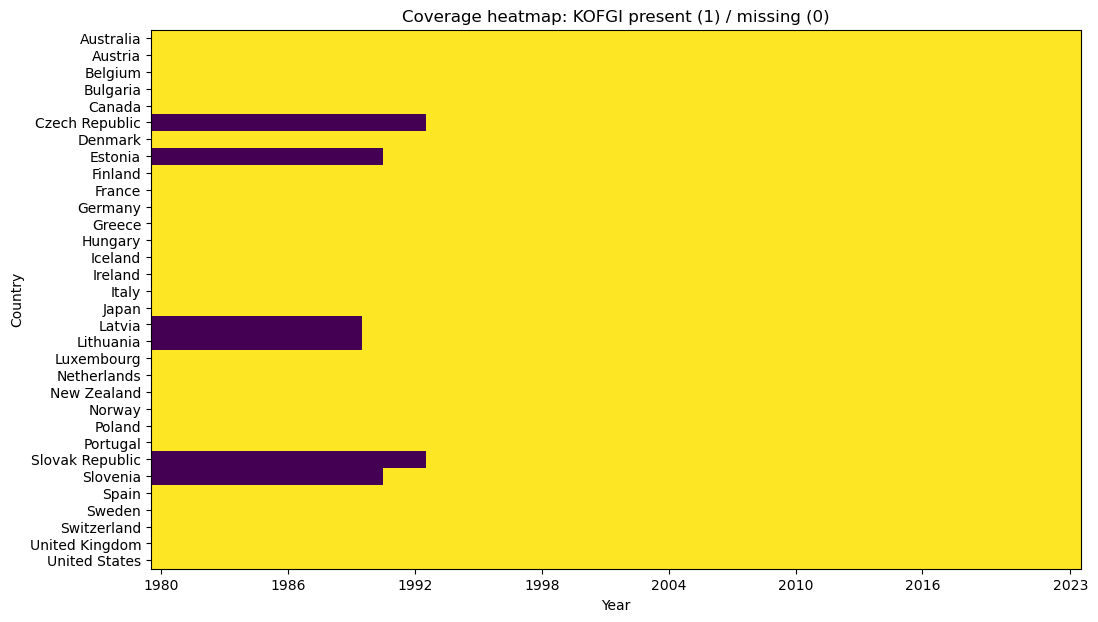

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Create a presence matrix: 1 if value exists
presence = (
    df_32.assign(present=df_32[ycol].notna().astype(int))
        .pivot_table(index="country", columns="year", values="present", aggfunc="max", fill_value=0)
        .sort_index()
)

plt.figure(figsize=(12, 7))
plt.imshow(presence.values, aspect="auto")
plt.yticks(range(len(presence.index)), presence.index)
plt.xticks(
    ticks=np.linspace(0, presence.shape[1]-1, 8).astype(int),
    labels=presence.columns[np.linspace(0, presence.shape[1]-1, 8).astype(int)],
    rotation=0
)
plt.title(f"Coverage heatmap: {ycol} present (1) / missing (0)")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()


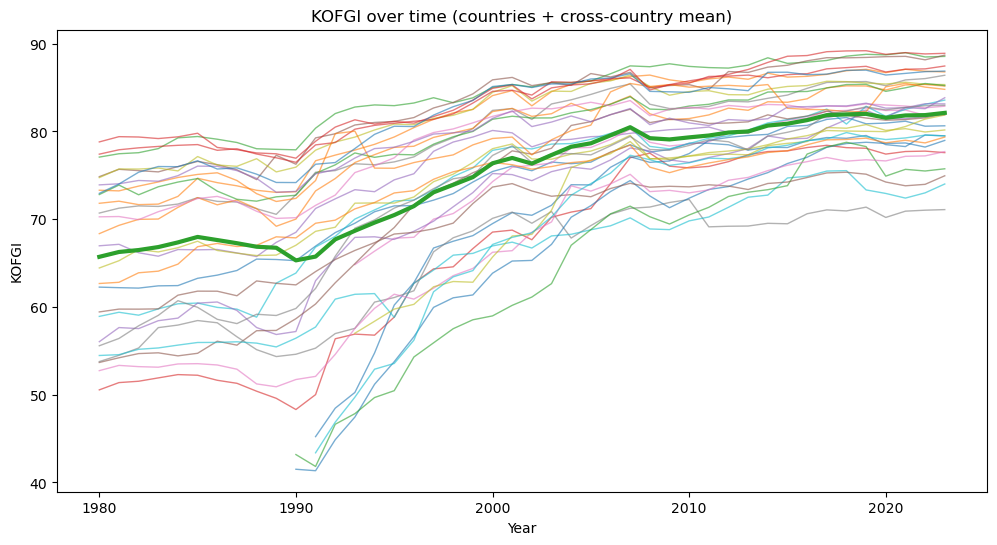

In [25]:
plt.figure(figsize=(12, 6))

for iso3, g in df_32.dropna(subset=[ycol]).groupby("iso3"):
    g = g.sort_values("year")
    plt.plot(g["year"], g[ycol], linewidth=1, alpha=0.6)

# Cross-country mean by year
mean_series = df_32.groupby("year")[ycol].mean()
plt.plot(mean_series.index, mean_series.values, linewidth=3)

plt.title(f"{ycol} over time (countries + cross-country mean)")
plt.xlabel("Year")
plt.ylabel(ycol)
plt.show()


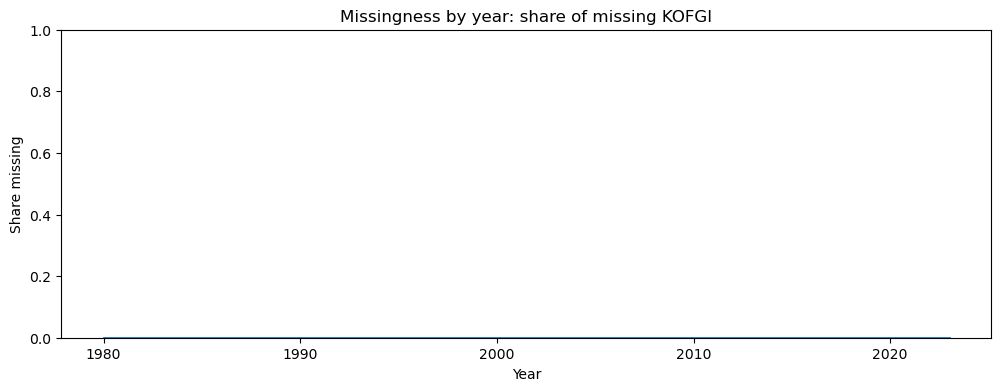

In [23]:
miss_by_year = df_32.groupby("year")[ycol].apply(lambda s: s.isna().mean())

plt.figure(figsize=(12, 4))
plt.plot(miss_by_year.index, miss_by_year.values, linewidth=2)
plt.title(f"Missingness by year: share of missing {ycol}")
plt.xlabel("Year")
plt.ylabel("Share missing")
plt.ylim(0, 1)
plt.show()


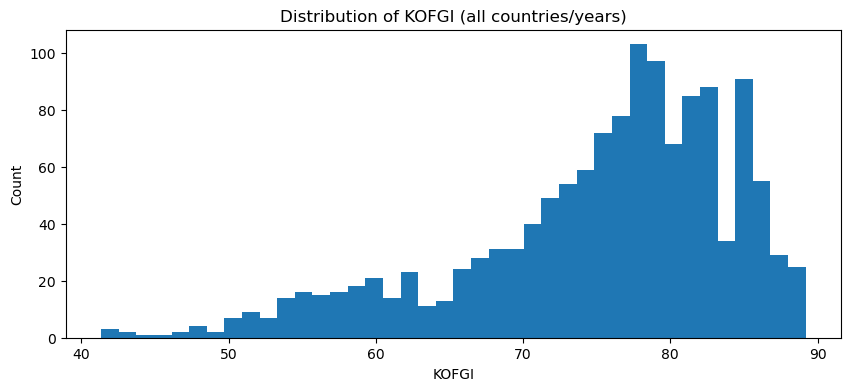

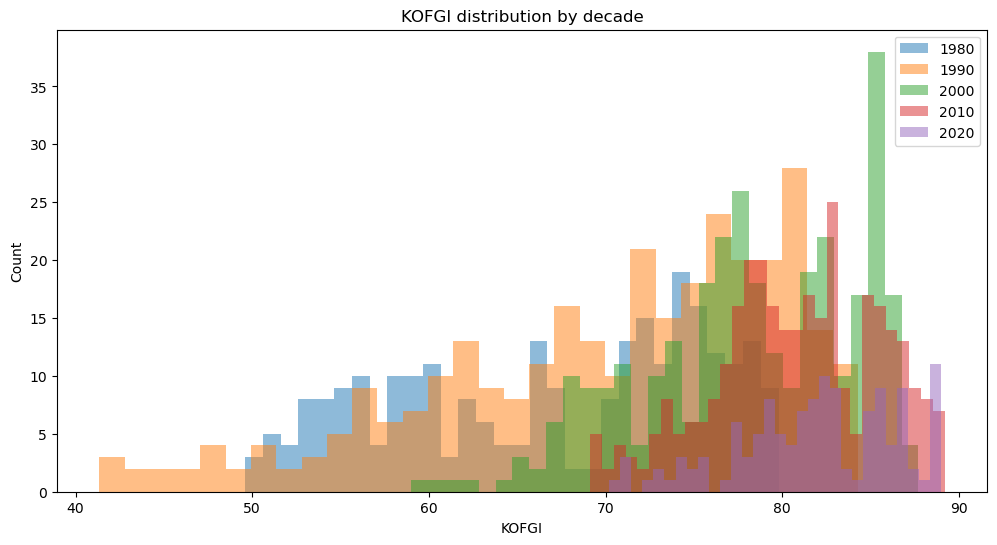

In [24]:
vals = df_32[ycol].dropna()

plt.figure(figsize=(10, 4))
plt.hist(vals, bins=40)
plt.title(f"Distribution of {ycol} (all countries/years)")
plt.xlabel(ycol)
plt.ylabel("Count")
plt.show()

# By decade
tmp = df_32.dropna(subset=[ycol]).copy()
tmp["decade"] = (tmp["year"] // 10) * 10

decades = sorted(tmp["decade"].unique())
plt.figure(figsize=(12, 6))
for d in decades:
    v = tmp.loc[tmp["decade"] == d, ycol]
    plt.hist(v, bins=30, alpha=0.5, label=str(d))
plt.title(f"{ycol} distribution by decade")
plt.xlabel(ycol)
plt.ylabel("Count")
plt.legend()
plt.show()


## GDP per capita

In [38]:
from pathlib import Path
import sys

# repo root = parent of /notebooks
REPO_ROOT = Path.cwd().resolve().parents[0]
SRC_PATH = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("REPO_ROOT:", REPO_ROOT)
print("SRC_PATH exists:", SRC_PATH.exists())


REPO_ROOT: C:\Users\Anton\economics-of-the-welfare-state
SRC_PATH exists: True


In [39]:
from clean.gdppc import (
    GDPPCConfig,
    read_gdppc_excel,
    standardize_gdppc_to_long,
    map_country_to_iso3,
    report_unmapped_countries,
    filter_32_and_log,
    save_processed,
)

print("Imports OK ✅")


Imports OK ✅


In [40]:
GDP_RAW = REPO_ROOT / "data" / "raw" / "GDP_per_capita.xlsx"

OUT_GDP_PARQUET = REPO_ROOT / "data" / "processed" / "gdppc_32countries_1980_2023.parquet"
OUT_GDP_CSV = REPO_ROOT / "data" / "processed" / "gdppc_32countries_1980_2023.csv"

print("GDP_RAW exists:", GDP_RAW.exists())
print("Output folder:", OUT_GDP_PARQUET.parent)


GDP_RAW exists: True
Output folder: C:\Users\Anton\economics-of-the-welfare-state\data\processed


In [41]:
import pandas as pd

xls = pd.ExcelFile(GDP_RAW)
print("Sheets:", xls.sheet_names)


Sheets: ['Table', 'Overview']


In [45]:
cfg_gdp = GDPPCConfig(
    year_min=1980,
    year_max=2023,
    strict_32=False,
    country_col="Reference area"   # <-- important for your file
)

df_gdp_raw = read_gdppc_excel(GDP_RAW, sheet_name="Table")


print("Raw shape:", df_gdp_raw.shape)
print("Columns:", df_gdp_raw.columns.tolist())
df_gdp_raw.head()


Raw shape: (41, 49)
Columns: ['Unnamed: 0', 'Annual GDP and consumption per capita  - multilateral indices', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48']


,Unnamed: 0,Annual GDP and consumption per capita - multilateral indices,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48
0,NaN,Institutional sector: Total economy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Counterpart institutional sector: Total economy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,"Transaction: Gross domestic product, per capita",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Price base: Chain linked volume (rebased),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

# CPDS (Comparative Political Data Set)

Process social spending transfers (sstran), deficit, and debt data for the 32 countries.

In [ ]:
# CPDS data paths
CPDS_RAW = REPO_ROOT / "data" / "raw" / "cpds_raw.xlsx"
CPDS_OUT_PARQUET = REPO_ROOT / "data" / "processed" / "cpds_32countries_1980_2023.parquet"
CPDS_OUT_CSV = REPO_ROOT / "data" / "processed" / "cpds_32countries_1980_2023.csv"

print("CPDS_RAW exists:", CPDS_RAW.exists())

In [ ]:
# Import CPDS cleaning utilities
from clean.cpds import (
    read_cpds_excel,
    standardize_cpds,
    filter_cpds_32countries,
    save_cpds,
)

print("Imported CPDS cleaning utilities successfully.")

## Load CPDS Excel file

In [ ]:
# Load raw CPDS data
df_cpds_raw = read_cpds_excel(CPDS_RAW)

print("Raw CPDS shape:", df_cpds_raw.shape)
print("Columns:", df_cpds_raw.columns.tolist()[:20], "..." if len(df_cpds_raw.columns) > 20 else "")
df_cpds_raw.head()

## Standardize and filter to 32 countries

In [ ]:
# Standardize column types
df_cpds_std = standardize_cpds(df_cpds_raw)

# Filter to 32 countries and required variables (sstran, deficit, debt)
df_cpds_32 = filter_cpds_32countries(
    df_cpds_std,
    year_min=1980,
    year_max=2023
)

print("Filtered CPDS (32 countries) shape:", df_cpds_32.shape)
print("Columns:", df_cpds_32.columns.tolist())
df_cpds_32.head()

## Data quality checks

In [ ]:
# Check country and year coverage
print("✅ Countries:", df_cpds_32["country"].nunique())
print("✅ Year range:", int(df_cpds_32["year"].min()), "-", int(df_cpds_32["year"].max()))
print()

# Check for duplicates
dup = df_cpds_32.duplicated(subset=["country", "year"]).sum()
print("Duplicate (country, year) rows:", dup)
print()

# Check missingness in key variables
print("Missing values by column:")
print(df_cpds_32.isnull().sum())
print()

# Quick look at coverage by country
df_cpds_32.groupby("country")["year"].agg(["min", "max", "count"]).sort_values("count")

## Save processed CPDS data

In [ ]:
# Save as both parquet and CSV
save_cpds(df_cpds_32, CPDS_OUT_PARQUET)
save_cpds(df_cpds_32, CPDS_OUT_CSV)

print("✅ Saved CPDS outputs:", CPDS_OUT_PARQUET.name, "and", CPDS_OUT_CSV.name)

## Quick reload test

In [ ]:
# Reload to verify file is valid
df_cpds_reload = pd.read_parquet(CPDS_OUT_PARQUET)

print("Reloaded CPDS shape:", df_cpds_reload.shape)
df_cpds_reload.head()

---

# Population Data

Process World Bank population data: compute ln(population) for the 32 countries.

In [ ]:
# Population data paths
POP_RAW = REPO_ROOT / "data" / "raw" / "Population_raw.xlsx"
POP_OUT_PARQUET = REPO_ROOT / "data" / "processed" / "population_32countries_1980_2023.parquet"
POP_OUT_CSV = REPO_ROOT / "data" / "processed" / "population_32countries_1980_2023.csv"

print("POP_RAW exists:", POP_RAW.exists())

In [ ]:
# Import population cleaning utilities
from clean.population import (
    PopulationConfig,
    read_population_excel,
    standardize_worldbank_population_to_long,
    filter_32_and_log,
    save_processed as save_pop,
)

print("Imported population cleaning utilities successfully.")

## Load Population Excel file (World Bank format)

In [ ]:
# Load raw population data from World Bank
df_pop_raw = read_population_excel(POP_RAW)

print("Raw population shape:", df_pop_raw.shape)
print("Columns (first 10):", df_pop_raw.columns.tolist()[:10], "..." if len(df_pop_raw.columns) > 10 else "")
df_pop_raw.head()

## Convert from wide to long format

In [ ]:
# Convert World Bank wide format to long format (iso3, year, population)
df_pop_long = standardize_worldbank_population_to_long(df_pop_raw)

print("Long format shape:", df_pop_long.shape)
print("Columns:", df_pop_long.columns.tolist())
df_pop_long.head(10)

## Filter to 32 countries and compute ln(population)

In [ ]:
# Filter to 32 countries, year range 1980-2023, and compute ln(population)
cfg_pop = PopulationConfig(
    year_min=1980,
    year_max=2023,
    strict_32=False  # Set to True to enforce all 32 countries are present
)

df_pop_32 = filter_32_and_log(df_pop_long, cfg=cfg_pop)

print("Filtered population (32 countries) shape:", df_pop_32.shape)
print("Columns:", df_pop_32.columns.tolist())
df_pop_32.head()

## Data quality checks

In [ ]:
# Check country and year coverage
print("✅ Countries:", df_pop_32["iso3"].nunique())
print("✅ Year range:", int(df_pop_32["year"].min()), "-", int(df_pop_32["year"].max()))
print()

# Check for duplicates
dup = df_pop_32.duplicated(subset=["iso3", "year"]).sum()
print("Duplicate (iso3, year) rows:", dup)
print()

# Check missing values
print("Missing values:")
print(df_pop_32.isnull().sum())
print()

# Coverage by country
print("Coverage by country:")
df_pop_32.groupby("iso3")["year"].agg(["min", "max", "count"]).sort_values("count").tail(10)

## Save processed population data

In [ ]:
# Save ln_population dataset (iso3, year, ln_population only)
save_pop(df_pop_32, POP_OUT_PARQUET)
save_pop(df_pop_32, POP_OUT_CSV)

print("✅ Saved population outputs:", POP_OUT_PARQUET.name, "and", POP_OUT_CSV.name)

## Quick reload test

In [ ]:
# Reload to verify file is valid
df_pop_reload = pd.read_parquet(POP_OUT_PARQUET)

print("Reloaded population shape:", df_pop_reload.shape)
print("Sample of ln_population values:")
df_pop_reload.head()